## TP2

### Arbres de décisions

Nous allons utiliser le module [sklearn.tree.DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) pour prédire les classes.
Nous allons dans la suite du TP uniquement étudier les arbres de décisions et des techniques ensemblistes utilisant ces arbres. Nous illustrerons certains comportements uniquement sur les jeux de données _iris_ et _digits_.

_iris_ que vous connaissez bien et qui est relativement petit et simple doit vous permettre de vérifier votre code et certaines hypothèse.

_digits_ représente plus de difficulté et doit être utilisé pour l'analyse finale de vos résultats.

**§ Est-il nécessaire de normaliser ces jeux de données et pourquoi ?**


Ce n'est pas utile car les variables sont indépendantes.


Le module de sklearn _DecisionTreeClassifier_ présente plusieurs paramètres pouvant être instanciés pour modifier le comportement de l'algorithme.
Intéressons nous aux paramètres : max_depth, max_features and random_state.

**§ Expliquer le rôle de ces trois paramètres et quelles valeurs ils peuvent prendre**


`max_depth` &rarr; contrôle la profondeur maximale de l'arbre et permet notamment de limiter le surapprentissage. Il peut être égal à None ou à un entier positif. \
`max_features` &rarr; détermine le nombre de caractéristiques prises en compte lors de la recherche de la meilleure séparation. Il peut prendre les valeurs None, un entier, un flottant, "sqrt" ou "log2". \
`random_state` &rarr; fixe la graine aléatoire afin de rendre les résultats reproductibles. Il peut être égal à None ou à un entier.


Fixons ```random_state=2``` et  ```max_features=None``` puis faisons prendre les valeurs {1,2,4,None} à ```max_depth```.

Considérons deux ensembles _train_ et _test_ comme construits précédement à partir de la totalité du jeux de données (ici, avec un ```random_state=3```) en faisant varier les valeurs de ```test_size``` dans l'ensemble {0.20,0.33,0.5}.

**§ Discuter le choix des valeurs du paramètre ```max_depth``` et de la taille de l'ensemble de test**


In [26]:
import sklearn
from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

j_iris = load_iris()
j_digits = load_digits()

X, Y = j_iris.data, j_iris.target
# X, Y = j_digits.data, j_digits.target

RANDOM_STATE = 2
MAX_FEATURES = None
MAX_DEPTHS = [1, 2, 4, None]
TEST_SIZES = [0.20, 0.33, 0.50]
SAVE_DATA = {
    "iris": [],
    "digits": []
}

for data in [0, 1]:
    if (data == 0):
        X, Y = j_iris.data, j_iris.target
    else:
        X, Y = j_digits.data, j_digits.target

    for size in TEST_SIZES:
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=size, random_state=RANDOM_STATE)

        for max_depth in MAX_DEPTHS:
            dt = DecisionTreeClassifier(max_features=MAX_FEATURES, max_depth=max_depth, random_state=RANDOM_STATE)

            dt.fit(X_train, Y_train)
            test_score = dt.score(X_test, Y_test)

            if (data == 0):
                SAVE_DATA['iris'].append({"size": size, "max_depth": max_depth, "real_depth": dt.tree_.max_depth, "accurancy": test_score})
            else:
                SAVE_DATA['digits'].append({"size": size, "max_depth": max_depth, "real_depth": dt.tree_.max_depth, "accurancy": test_score})

            print(
                f"size={size}",
                f"max_depth={max_depth}, "
                f"profondeur réelle={dt.tree_.max_depth}, "
                f"test={test_score:.3f}"
            )

size=0.2 max_depth=1, profondeur réelle=1, test=0.733
size=0.2 max_depth=2, profondeur réelle=2, test=0.933
size=0.2 max_depth=4, profondeur réelle=4, test=0.933
size=0.2 max_depth=None, profondeur réelle=4, test=0.933
size=0.33 max_depth=1, profondeur réelle=1, test=0.680
size=0.33 max_depth=2, profondeur réelle=2, test=0.940
size=0.33 max_depth=4, profondeur réelle=4, test=0.960
size=0.33 max_depth=None, profondeur réelle=4, test=0.960
size=0.5 max_depth=1, profondeur réelle=1, test=0.667
size=0.5 max_depth=2, profondeur réelle=2, test=0.947
size=0.5 max_depth=4, profondeur réelle=4, test=0.947
size=0.5 max_depth=None, profondeur réelle=4, test=0.947
size=0.2 max_depth=1, profondeur réelle=1, test=0.181
size=0.2 max_depth=2, profondeur réelle=2, test=0.275
size=0.2 max_depth=4, profondeur réelle=4, test=0.544
size=0.2 max_depth=None, profondeur réelle=15, test=0.836
size=0.33 max_depth=1, profondeur réelle=1, test=0.195
size=0.33 max_depth=2, profondeur réelle=2, test=0.308
size=0.33

Plus la profondeur est élévé meilleur est le résultat. En ce qui concerne les taille il n'y a pas de grand changement.


Vous pouvez afficher l'arbre de décision (sous format graphique ou texte) en important respectivement des modules via les commandes ```from sklearn import tree``` et ```from sklearn.tree import export_text```.

La profondeur de l'arbre construit est accessible via ```dt.tree_.max_depth``` où dt est un _DecisionTreeClassifier_.

**§ A quelle métrique correspond le score calculé ?**


C'est l'accurancy.


**§ Reporter dans un tableau (à deux dimensions) les résultats de score pour ces valeurs de paramètres pour les deux jeux de données : iris puis digits**


In [27]:
for (key,values) in SAVE_DATA.items():
    print(key)
    for value in values:
        print(value)

iris
{'size': 0.2, 'max_depth': 1, 'real_depth': 1, 'accurancy': 0.7333333333333333}
{'size': 0.2, 'max_depth': 2, 'real_depth': 2, 'accurancy': 0.9333333333333333}
{'size': 0.2, 'max_depth': 4, 'real_depth': 4, 'accurancy': 0.9333333333333333}
{'size': 0.2, 'max_depth': None, 'real_depth': 4, 'accurancy': 0.9333333333333333}
{'size': 0.33, 'max_depth': 1, 'real_depth': 1, 'accurancy': 0.68}
{'size': 0.33, 'max_depth': 2, 'real_depth': 2, 'accurancy': 0.94}
{'size': 0.33, 'max_depth': 4, 'real_depth': 4, 'accurancy': 0.96}
{'size': 0.33, 'max_depth': None, 'real_depth': 4, 'accurancy': 0.96}
{'size': 0.5, 'max_depth': 1, 'real_depth': 1, 'accurancy': 0.6666666666666666}
{'size': 0.5, 'max_depth': 2, 'real_depth': 2, 'accurancy': 0.9466666666666667}
{'size': 0.5, 'max_depth': 4, 'real_depth': 4, 'accurancy': 0.9466666666666667}
{'size': 0.5, 'max_depth': None, 'real_depth': 4, 'accurancy': 0.9466666666666667}
digits
{'size': 0.2, 'max_depth': 1, 'real_depth': 1, 'accurancy': 0.180555555


**§ Pourquoi n'est-il pas pertinent d'analyser ces résultats tels quels ?**


On regarde pour un seul seed, cela ne veut pas dire que pour d'autre on aurait le même résultat. 


**§ Adapter le protocole expérimental. Analyser ces nouveaux résultats pour _iris_ puis _digits_**

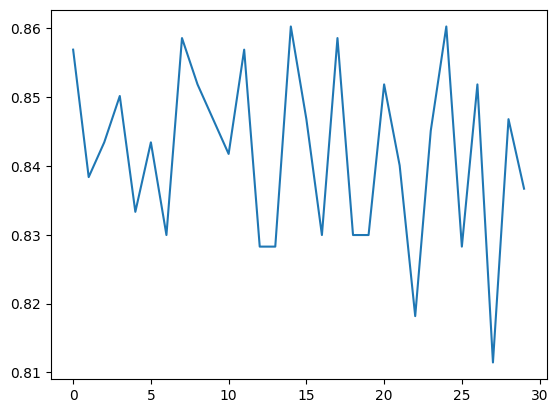

In [28]:
import matplotlib.pyplot as plt

X, Y = j_digits.data, j_digits.target

SIZE = 0.33
DEPTH = None

result = []

for seed in range(1, 31):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=SIZE, random_state=seed)
    dt = DecisionTreeClassifier(max_features=MAX_FEATURES, max_depth=DEPTH, random_state=seed)
    dt.fit(X_train, Y_train)
    test_score = dt.score(X_test, Y_test)
    result.append(test_score)

plt.plot(result)
plt.show()

Maintenant intéressons nous à la méthodologie d'entrainement avec un jeu de données. Jusqu'ici nous avons utilisé la méthode qui consiste à séparer le jeu de données pour obtenir un jeu d'entrainement et un jeu de test. Etudions ici l'intérêt de la [validation croisée](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation). Pour cela, plusieurs modules sont disponibles sous sklearn. Le module ```cross_val_score``` est l'un d'entre eux et il peut être importer via la commande 
```from sklearn.model_selection import cross_val_score```.

Pour commencer, instancions un arbre de décision comme suit : 
```dt = tree.DecisionTreeClassifier(random_state=2,max_depth=4)```

Pour obtenir (et afficher) le résultat de cette instanciation sur le jeu de données (complet) X et la classe associée y par validation croisée, il suffit d'exécuter la commande : 
```cross_val_score(dt, X, y, cv=5)```


Il existe plusieurs techniques classiques de validation croisée : 
* K-fold (commande ```from sklearn.model_selection import KFold```)
* Stratified K-fold (commande ```from sklearn.model_selection import StratifiedKFold```)
* Repeated K-fold (commande ```from sklearn.model_selection import RepeatedKFold```)
* Repeated Stratified K-fold (commande ```from sklearn.model_selection import RepeatedStratifiedKFold```)
* LeaveOneOut (commande ```from sklearn.model_selection import LeaveOneOut```)

**§ Regarder la doc en ligne et expliquer ces cinq techniques de validation croisée**


| Méthode                   | Principe                                            | Avantage principal                                | Inconvénient                                          |
| ------------------------- | --------------------------------------------------- | ------------------------------------------------- | ----------------------------------------------------- |
| `KFold`                   | K groupes, chacun sert une fois de validation       | Simple et efficace                                | Ne conserve pas forcément les proportions des classes |
| `StratifiedKFold`         | KFold avec conservation des proportions des classes | Adapté à la classification                        | Un peu plus spécifique                                |
| `RepeatedKFold`           | Répète KFold plusieurs fois                         | Score plus robuste                                | Plus coûteux                                          |
| `RepeatedStratifiedKFold` | Répète StratifiedKFold                              | Robuste + préserve les classes                    | Plus coûteux                                          |
| `LeaveOneOut`             | 1 individu en validation à chaque fois              | Utilise presque toutes les données pour apprendre | Très coûteux                                          |



**§ Regarder la doc en ligne du module ```cross_val_score``` et expliquer la méthode de validation croisée effectuée**


Considérons uniquement le jeu de données _iris_.

Prenons par exemple pour la méthode K-fold, la commande ```kf = KFold(n_splits=5)``` instancie un objet kf afin de faire une validation croisée 5-fold et la commande ```cross_val_score(dt, X, y, cv=kf)``` exécute la validation croisée 5-fold en utilsant le modèle KFold. Le code ci-dessous exécute 10 fois la validation croisée selon la technique KFold et construit 10 fois 5 modèle.


```
for i in range(10):
    cvkf=cross_val_score(dt, X, y, cv=kf)
    print(cvkf)
```


In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)

for i in range(10):
    cvkf=cross_val_score(dt, X, Y, cv=kf)
    print(cvkf)

[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]
[0.76666667 0.73611111 0.80501393 0.84122563 0.78272981]



**§ Pourquoi les 5 mêmes modèles sont construits 10 fois ? Faut-il modifier le code qui définit l'arbre de décision et/ou le KFold ?**


Par défaut, KFold utilise shuffle=False, donc il découpe toujours les données de la même façon.

In [31]:
for i in range(10):
    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=i
    )

    cvkf=cross_val_score(dt, X, Y, cv=kf)
    print(cvkf)

[0.85       0.86111111 0.85236769 0.88022284 0.8356546 ]
[0.84722222 0.83611111 0.84958217 0.82172702 0.84958217]
[0.82222222 0.84166667 0.81615599 0.83286908 0.84958217]
[0.85277778 0.83055556 0.86629526 0.84122563 0.87743733]
[0.85555556 0.83055556 0.8551532  0.8718663  0.79387187]
[0.86388889 0.86388889 0.84401114 0.84679666 0.80779944]
[0.85555556 0.87777778 0.8551532  0.8551532  0.85236769]
[0.84166667 0.86111111 0.85793872 0.86629526 0.81615599]
[0.83888889 0.86944444 0.85236769 0.83844011 0.83844011]
[0.84444444 0.83055556 0.83844011 0.8551532  0.83844011]




Tester les 5 techniques avec l'arbre de décision précédent et les valeurs ```n_splits=5``` et ```n_repeats=6``` lorsque c'est applicable. 

La moyenne des accuracy est accessible via la méthode ```.mean()``` du module ```cross_val_score```.


**§ Exécuter les 5 techniques et afficher pour chacune la moyenne des accuracy sur le test pour les deux jeux de données _iris_ puis _digits_**


Le module ```cross_validate``` est un autre module permettant d'utiliser la validation croisée. 

**§ Regarder la doc en ligne et préciser ce que le module ```cross_validate``` permet de faire en plus de ```cross_val_score```**

Maintenant on se restreint aux techniques de validation croisées _Repeated_ et _LeaveOneOut_. Définir 5 variantes d'arbres de décision en jouant sur les paramètres ```max_depth``` et ```max_features```.

**§ Pour le jeu de données _digits_, exécuter les 3 techniques de validation croisée avec ```cross_validate``` et analyser les performances en terme de prédiction et de durée**


**§ Quel peut être l'intérêt de la validation croisée par rapport au découpage train/test du jeu de données ?**